<a href="https://colab.research.google.com/github/Abdil2146/tugas-data-science-kelompok/blob/main/Analisis_PCA_tSNE_Film_Populer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Praktik Dimensionality Reduction (PCA dan t-SNE)

## Visualisasi dan Eksplorasi Pola Film Populer Menggunakan PCA dan t-SNE


**Kelompok :**  
1. Muhammad Abdillah Mu'tashim – NIM(24523239)
2. Hiraldy ibrahim – NIM(24523176)
3. Muhamad Aldio Khairullah Santoso – NIM(24523250)
4. irham malik taufik – NIM(24523030)

**Mata Kuliah :** Fundamen sains data

**Dosen Pengampu :** Ahmad Fathan Hidayatullah, S.T.

**Kelas :** A

## Pendahuluan

Pada tugas ini digunakan dataset **Top 1000 Popular Movies TMDB** yang berisi informasi mengenai film-film populer, seperti rating, jumlah vote, tingkat popularitas, budget, revenue, runtime, dan tahun rilis. Dataset ini cukup menarik untuk dianalisis karena setiap film memiliki beberapa karakteristik numerik yang bisa dibandingkan satu sama lain.

Masalahnya, ketika jumlah fitur cukup banyak, pola hubungan antarfilm akan sulit dilihat jika hanya mengandalkan tabel data biasa. Oleh karena itu, dibutuhkan teknik **dimensionality reduction** untuk menyederhanakan data ke dimensi yang lebih rendah tanpa menghilangkan informasi penting secara keseluruhan.

Pada notebook ini digunakan dua metode dimensionality reduction, yaitu **PCA (Principal Component Analysis)** dan **t-SNE (t-Distributed Stochastic Neighbor Embedding)**. Keduanya digunakan untuk memetakan data film ke dalam ruang dua dimensi agar pola persebaran data dan kemungkinan pengelompokan film bisa terlihat dengan lebih jelas.

## Tujuan Analisis

Adapun tujuan dari analisis ini adalah sebagai berikut:

1. Menyiapkan dataset film populer agar dapat digunakan dalam proses analisis.
2. Memilih fitur-fitur numerik yang relevan untuk dimensionality reduction.
3. Menerapkan metode PCA dan t-SNE pada dataset.
4. Menampilkan hasil reduksi dimensi dalam bentuk visualisasi dua dimensi.
5. Membandingkan hasil PCA dan t-SNE untuk melihat metode mana yang lebih informatif dalam menggambarkan pola data film.

## Import Library

Pada tahap awal, dilakukan import library yang diperlukan untuk membaca dataset, melakukan preprocessing, standardisasi data, menjalankan PCA dan t-SNE, serta menampilkan visualisasi hasil analisis.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

sns.set(style="whitegrid")
plt.style.use("default")

## Upload Dataset

Dataset yang digunakan pada analisis ini diambil dari Kaggle, yaitu dataset **Top 1000 Popular Movies TMDB**.

In [38]:
from google.colab import files
uploaded = files.upload()

Saving top_1000_popular_movies_tmdb.csv to top_1000_popular_movies_tmdb (3).csv


## Membaca Dataset

Setelah file berhasil di-upload, langkah berikutnya adalah memeriksa nama file yang tersimpan di direktori Colab, lalu membaca dataset menggunakan library **pandas**. Pada tahap ini juga akan ditampilkan beberapa baris awal data untuk memastikan dataset sudah berhasil dimuat dengan benar.

In [39]:
import os
print(os.listdir())

['.config', 'top_1000_popular_movies_tmdb (3).csv', 'top_1000_popular_movies_tmdb (2).csv', 'top_1000_popular_movies_tmdb (1).csv', 'top_1000_popular_movies_tmdb.csv', 'sample_data']


In [40]:
df = pd.read_csv("top_1000_popular_movies_tmdb.csv", engine="python", on_bad_lines="skip")
df.head()

,Unnamed: 0,id,title,release_date,genres,original_language,vote_average,vote_count,popularity,overview,budget,production_companies,revenue,runtime,tagline
0,0,385687,Fast X,2023-05-17,"['Action', 'Crime', 'Thriller']",English,7.4,1347.0,8363.473,Over many missions and against impossible odds...,340000000.0,"['Universal Pictures', 'Original Film', 'One R...",6.520000e+08,142.0,The end of the road begins.
1,1,603692,John Wick: Chapter 4,2023-03-22,"['Action', 'Thriller', 'Crime']",English,7.9,2896.0,4210.313,"With the price on his head ever increasing, Jo...",90000000.0,"['Thunder Road', '87Eleven', 'Summit Entertain...",4.317692e+08,170.0,"No way back, one way out."
2,2,502356,The Super Mario Bros. Movie,2023-04-05,"['Animation', 'Family', 'Adventure', 'Fantasy'...",English,7.8,4628.0,3394.458,"While working underground to fix a water main,...",100000000.0,"['Universal Pictures', 'Illumination', 'Ninten...",1.308767e+09,92.0,NaN
3,3,569094,Spider-Man: Across the Spider-Verse,2023-05-31,"['Action', 'Adventure', 'Animation', 'Science ...",English,8.8,1160.0,2859.047,"After reuniting with Gwen Stacy, Brooklyn’s fu...",100000000.0,"['Columbia Pictures', 'Sony Pictures Animation...",3.135222e+08,140.0,It's how you wear the mask that matters
4,4,536437,Hypnotic,2023-05-11,"['Mystery', 'Thriller', 'Science Fiction']",English,6.5,154.0,2654.854,A detective becomes entangled in a mystery inv...,70000000.0,"['Studio 8', 'Solstice Productions', 'Ingeniou...",0.000000e+00,94.0,Control is an illusion.


## Eksplorasi Data Awal

Sebelum masuk ke proses analisis, perlu dilakukan eksplorasi data terlebih dahulu. Tujuan tahap ini adalah untuk memahami struktur dataset, seperti jumlah baris dan kolom, nama-nama fitur, tipe data tiap kolom, serta melihat apakah terdapat missing value. Informasi ini penting untuk menentukan langkah preprocessing yang sesuai.

In [41]:
print("Shape dataset:", df.shape)
print("\nDaftar kolom:")
print(df.columns.tolist())

print("\nInfo dataset:")
df.info()

print("\nJumlah missing value per kolom:")
print(df.isnull().sum())

Shape dataset: (10001, 15)

Daftar kolom:
['Unnamed: 0', 'id', 'title', 'release_date', 'genres', 'original_language', 'vote_average', 'vote_count', 'popularity', 'overview', 'budget', 'production_companies', 'revenue', 'runtime', 'tagline']

Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10001 entries, 0 to 10000
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            10001 non-null  object 
 1   id                    10001 non-null  int64  
 2   title                 10001 non-null  object 
 3   release_date          9978 non-null   object 
 4   genres                10001 non-null  object 
 5   original_language     10000 non-null  object 
 6   vote_average          10000 non-null  float64
 7   vote_count            10000 non-null  float64
 8   popularity            10000 non-null  float64
 9   overview              9924 non-null   object 
 10  budget           

In [42]:
df.head()

,Unnamed: 0,id,title,release_date,genres,original_language,vote_average,vote_count,popularity,overview,budget,production_companies,revenue,runtime,tagline
0,0,385687,Fast X,2023-05-17,"['Action', 'Crime', 'Thriller']",English,7.4,1347.0,8363.473,Over many missions and against impossible odds...,340000000.0,"['Universal Pictures', 'Original Film', 'One R...",6.520000e+08,142.0,The end of the road begins.
1,1,603692,John Wick: Chapter 4,2023-03-22,"['Action', 'Thriller', 'Crime']",English,7.9,2896.0,4210.313,"With the price on his head ever increasing, Jo...",90000000.0,"['Thunder Road', '87Eleven', 'Summit Entertain...",4.317692e+08,170.0,"No way back, one way out."
2,2,502356,The Super Mario Bros. Movie,2023-04-05,"['Animation', 'Family', 'Adventure', 'Fantasy'...",English,7.8,4628.0,3394.458,"While working underground to fix a water main,...",100000000.0,"['Universal Pictures', 'Illumination', 'Ninten...",1.308767e+09,92.0,NaN
3,3,569094,Spider-Man: Across the Spider-Verse,2023-05-31,"['Action', 'Adventure', 'Animation', 'Science ...",English,8.8,1160.0,2859.047,"After reuniting with Gwen Stacy, Brooklyn’s fu...",100000000.0,"['Columbia Pictures', 'Sony Pictures Animation...",3.135222e+08,140.0,It's how you wear the mask that matters
4,4,536437,Hypnotic,2023-05-11,"['Mystery', 'Thriller', 'Science Fiction']",English,6.5,154.0,2654.854,A detective becomes entangled in a mystery inv...,70000000.0,"['Studio 8', 'Solstice Productions', 'Ingeniou...",0.000000e+00,94.0,Control is an illusion.


## Preprocessing Data

Data yang masih mentah biasanya belum bisa langsung digunakan untuk analisis. Oleh karena itu, pada tahap ini dilakukan beberapa proses pembersihan dan penyesuaian data, seperti menghapus kolom yang tidak diperlukan, mengubah format tanggal rilis menjadi tahun rilis, serta mengambil genre utama dari setiap film. Tujuannya agar data menjadi lebih rapi dan fitur yang digunakan benar-benar relevan dengan analisis dimensionality reduction.

### Menghapus Kolom yang Tidak Digunakan

Tidak semua kolom pada dataset digunakan dalam proses PCA dan t-SNE. Beberapa kolom seperti identitas film atau deskripsi teks tidak dipakai sebagai fitur utama karena fokus analisis ini ada pada atribut numerik film. Oleh sebab itu, kolom-kolom yang tidak relevan akan dihapus agar proses pengolahan data menjadi lebih sederhana.

In [43]:
df = df.drop(columns=["Unnamed: 0", "id", "overview", "tagline", "production_companies"], errors="ignore")

### Mengubah Tanggal Rilis Menjadi Tahun Rilis

Kolom `release_date` awalnya masih berupa tanggal lengkap. Pada analisis ini, informasi yang lebih dibutuhkan adalah **tahun rilis**, sehingga kolom tersebut diubah ke format datetime lalu diambil bagian tahunnya saja. Tahun rilis nantinya digunakan sebagai salah satu fitur numerik dalam proses analisis.

In [44]:
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["release_year"] = df["release_date"].dt.year

### Menentukan Genre Utama Film

Kolom `genres` pada dataset berisi daftar genre untuk setiap film. Agar lebih mudah digunakan saat visualisasi, diambil **genre pertama** sebagai representasi genre utama film. Genre utama ini nantinya akan dipakai sebagai pembeda warna pada scatter plot PCA dan t-SNE.

In [45]:
def get_main_genre(genre_str):
    try:
        genre_list = ast.literal_eval(genre_str)
        if isinstance(genre_list, list) and len(genre_list) > 0:
            return genre_list[0]
        return "Unknown"
    except:
        return "Unknown"

df["main_genre"] = df["genres"].apply(get_main_genre)

### Memilih Kolom yang Relevan

Setelah preprocessing awal dilakukan, langkah berikutnya adalah memilih kolom-kolom yang benar-benar akan digunakan dalam analisis. Kolom yang dipilih terdiri dari judul film, genre utama, bahasa asli, dan beberapa fitur numerik yang dianggap mewakili karakteristik penting film, seperti rating, jumlah vote, popularitas, budget, revenue, runtime, dan tahun rilis.

In [46]:
selected_columns = [
    "title",
    "main_genre",
    "original_language",
    "vote_average",
    "vote_count",
    "popularity",
    "budget",
    "revenue",
    "runtime",
    "release_year"
]

df_selected = df[selected_columns].copy()
df_selected.head()

,title,main_genre,original_language,vote_average,vote_count,popularity,budget,revenue,runtime,release_year
0,Fast X,Action,English,7.4,1347.0,8363.473,340000000.0,6.520000e+08,142.0,2023.0
1,John Wick: Chapter 4,Action,English,7.9,2896.0,4210.313,90000000.0,4.317692e+08,170.0,2023.0
2,The Super Mario Bros. Movie,Animation,English,7.8,4628.0,3394.458,100000000.0,1.308767e+09,92.0,2023.0
3,Spider-Man: Across the Spider-Verse,Action,English,8.8,1160.0,2859.047,100000000.0,3.135222e+08,140.0,2023.0
4,Hypnotic,Mystery,English,6.5,154.0,2654.854,70000000.0,0.000000e+00,94.0,2023.0


### Memeriksa Missing Value

Sebelum data dianalisis lebih lanjut, perlu dicek apakah terdapat nilai kosong pada fitur-fitur yang akan digunakan. Missing value pada fitur numerik dapat memengaruhi hasil analisis, terutama pada tahap standardisasi dan dimensionality reduction. Karena itu, pengecekan ini dilakukan agar data yang dipakai benar-benar siap diproses.

In [47]:
print(df_selected.isnull().sum())

title                 0
main_genre            0
original_language     1
vote_average          1
vote_count            1
popularity            1
budget                2
revenue               2
runtime               2
release_year         24
dtype: int64


### Membersihkan Data Kosong pada Fitur Utama

Baris data yang memiliki missing value pada fitur numerik utama akan dihapus. Langkah ini dilakukan supaya proses standardisasi, PCA, dan t-SNE dapat berjalan tanpa error dan hasil analisis tidak terganggu oleh data yang tidak lengkap.

In [48]:
feature_cols = [
    "vote_average",
    "vote_count",
    "popularity",
    "budget",
    "revenue",
    "runtime",
    "release_year"
]

df_clean = df_selected.dropna(subset=feature_cols).copy()
print("Jumlah data setelah menghapus missing value:", df_clean.shape)

Jumlah data setelah menghapus missing value: (9976, 10)


## Filter Genre untuk Visualisasi

Pada dataset film biasanya terdapat cukup banyak genre. Jika seluruh genre langsung ditampilkan dalam satu visualisasi, hasil scatter plot bisa terlihat terlalu padat dan sulit dibaca. Karena itu, pada tahap ini hanya dipilih genre yang jumlah datanya cukup banyak, sehingga visualisasi menjadi lebih jelas dan pola persebaran data lebih mudah diamati.

In [49]:
genre_counts = df_clean["main_genre"].value_counts()
top_genres = genre_counts[genre_counts >= 100].index

df_vis = df_clean[df_clean["main_genre"].isin(top_genres)].copy()

print("Jumlah data setelah filter genre:", df_vis.shape)
print("\nJumlah film per genre:")
print(df_vis["main_genre"].value_counts())

Jumlah data setelah filter genre: (9620, 10)

Jumlah film per genre:
main_genre
Drama              1942
Action             1542
Comedy             1400
Horror              882
Animation           826
Adventure           548
Thriller            543
Romance             439
Crime               384
Family              304
Science Fiction     297
Fantasy             248
Documentary         151
Mystery             114
Name: count, dtype: int64


## Hasil Penyaringan Genre

Pada tahap ini dilakukan penyaringan genre berdasarkan jumlah kemunculannya pada dataset. Genre yang dipertahankan adalah genre yang memiliki minimal 100 film agar visualisasi tidak terlalu didominasi oleh kategori yang jumlah datanya sangat sedikit. Setelah proses penyaringan, diperoleh **9.620 data film** dengan **13 genre utama** yang digunakan pada tahap visualisasi.

Distribusi jumlah film per genre menunjukkan bahwa **Drama**, **Action**, dan **Comedy** menjadi genre dengan jumlah data paling banyak, sedangkan genre seperti **Mystery** dan **Documentary** memiliki jumlah yang relatif lebih sedikit. Perbedaan jumlah ini perlu diperhatikan saat membaca visualisasi, karena genre dengan jumlah data besar cenderung tampak lebih dominan pada grafik.

## Menyiapkan Fitur Numerik

Tahap berikutnya adalah menyiapkan fitur-fitur numerik yang akan digunakan dalam proses dimensionality reduction. Fitur yang dipakai pada analisis ini meliputi:

- `vote_average`
- `vote_count`
- `popularity`
- `budget`
- `revenue`
- `runtime`
- `release_year`

Ketujuh fitur tersebut dipilih karena mewakili performa, popularitas, dan karakteristik produksi film secara umum.

In [50]:
X = df_vis[[
    "vote_average",
    "vote_count",
    "popularity",
    "budget",
    "revenue",
    "runtime",
    "release_year"
]]

## Standardisasi Data

Nilai pada tiap fitur numerik memiliki skala yang berbeda-beda. Sebagai contoh, `budget` dan `revenue` bisa bernilai sangat besar, sedangkan `vote_average` berada pada rentang yang jauh lebih kecil. Jika data langsung dianalisis tanpa standardisasi, fitur dengan skala besar akan lebih dominan. Oleh karena itu, dilakukan standardisasi menggunakan **StandardScaler** agar semua fitur berada pada skala yang sebanding.

In [51]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Principal Component Analysis (PCA)

Metode pertama yang digunakan adalah **PCA (Principal Component Analysis)**. PCA bekerja dengan mereduksi data ke beberapa komponen utama yang mampu menjelaskan variasi terbesar dari data asli. Pada analisis ini, data akan direduksi menjadi dua komponen utama agar hasilnya bisa divisualisasikan dalam bentuk scatter plot dua dimensi.

In [59]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["main_genre"] = df_vis["main_genre"].values
pca_df["title"] = df_vis["title"].values

### Explained Variance PCA

Setelah PCA dijalankan, akan dilihat nilai explained variance ratio dari dua komponen utama yang dihasilkan. Nilai ini menunjukkan seberapa besar variasi data yang bisa dijelaskan oleh masing-masing komponen.

In [53]:
explained_variance = pca.explained_variance_ratio_
print("Explained Variance Ratio:")
print("PC1:", explained_variance[0])
print("PC2:", explained_variance[1])
print("Total PC1 + PC2:", explained_variance.sum())

Explained Variance Ratio:
PC1: 0.3815089063261437
PC2: 0.1910701381313439
Total PC1 + PC2: 0.5725790444574876


### Visualisasi Hasil PCA

Hasil PCA divisualisasikan dalam bentuk scatter plot dua dimensi. Setiap titik merepresentasikan satu film, sedangkan warna titik menunjukkan genre utama film tersebut.

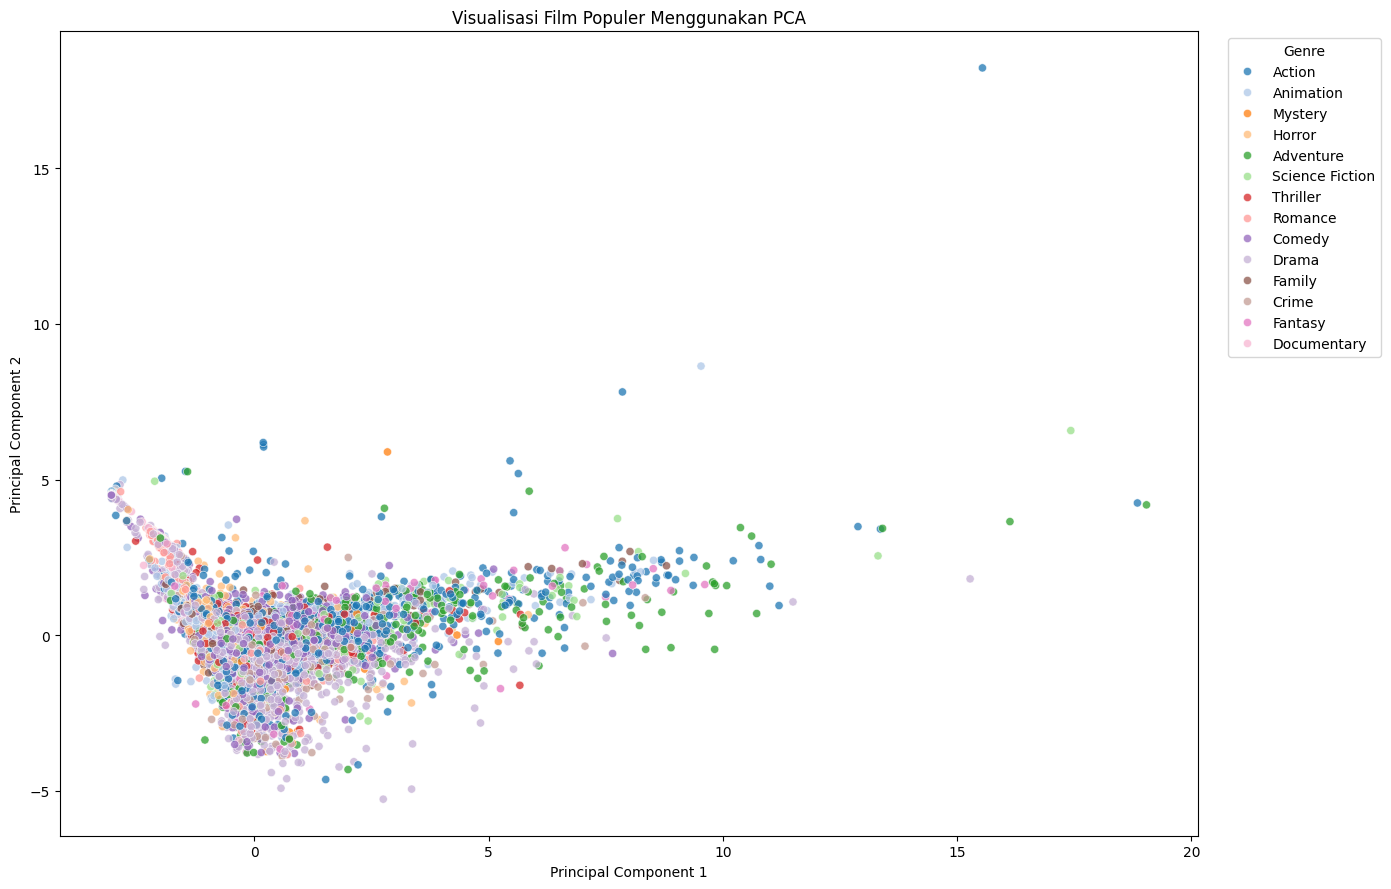

In [57]:
plt.figure(figsize=(14, 9))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="main_genre",
    palette="tab20",
    alpha=0.75,
    s=35
)
plt.title("Visualisasi Film Populer Menggunakan PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Genre", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Analisis Hasil PCA

Visualisasi PCA menunjukkan hasil reduksi dimensi data film ke dalam dua komponen utama. Secara umum, persebaran titik pada grafik masih cukup menyatu dan belum membentuk pemisahan genre yang benar-benar tegas. Beberapa titik tampak mengelompok pada area tertentu, tetapi sebagian besar genre masih saling bertumpang tindih.

Kondisi ini menunjukkan bahwa karakteristik numerik film seperti **vote average, vote count, popularity, budget, revenue, runtime,** dan **release year** belum cukup kuat untuk memisahkan genre secara linear. Dengan kata lain, film dari genre yang berbeda masih dapat memiliki pola numerik yang mirip, misalnya film drama dan romance yang sama-sama memiliki durasi atau rating yang tidak jauh berbeda.

Meskipun demikian, PCA tetap memberikan gambaran awal mengenai struktur global data. Dari visualisasi terlihat bahwa sebagian besar film terkonsentrasi pada area bawah grafik, sementara ada beberapa titik yang berada cukup jauh dari kumpulan utama. Titik-titik tersebut dapat dianggap sebagai data yang memiliki karakteristik numerik cukup berbeda dibandingkan film lainnya, misalnya dari sisi popularitas, pendapatan, atau jumlah vote.

## t-Distributed Stochastic Neighbor Embedding (t-SNE)

Metode kedua yang digunakan adalah **t-SNE**. Berbeda dengan PCA yang lebih menekankan struktur global data, t-SNE lebih fokus pada kedekatan lokal antar data. Karena itu, metode ini sering dipakai untuk melihat kemungkinan adanya pola pengelompokan data yang lebih jelas.

In [60]:
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=20,
    max_iter=1000
)

X_tsne = tsne.fit_transform(X_scaled)

tsne_df = pd.DataFrame(X_tsne, columns=["TSNE1", "TSNE2"])
tsne_df["main_genre"] = df_vis["main_genre"].values
tsne_df["title"] = df_vis["title"].values

tsne_df.head()

,TSNE1,TSNE2,main_genre,title
0,6.195533,104.430481,Action,Fast X
1,5.988358,104.122414,Action,John Wick: Chapter 4
2,5.917399,104.000237,Animation,The Super Mario Bros. Movie
3,5.746344,103.788635,Action,Spider-Man: Across the Spider-Verse
4,5.651165,103.706322,Mystery,Hypnotic


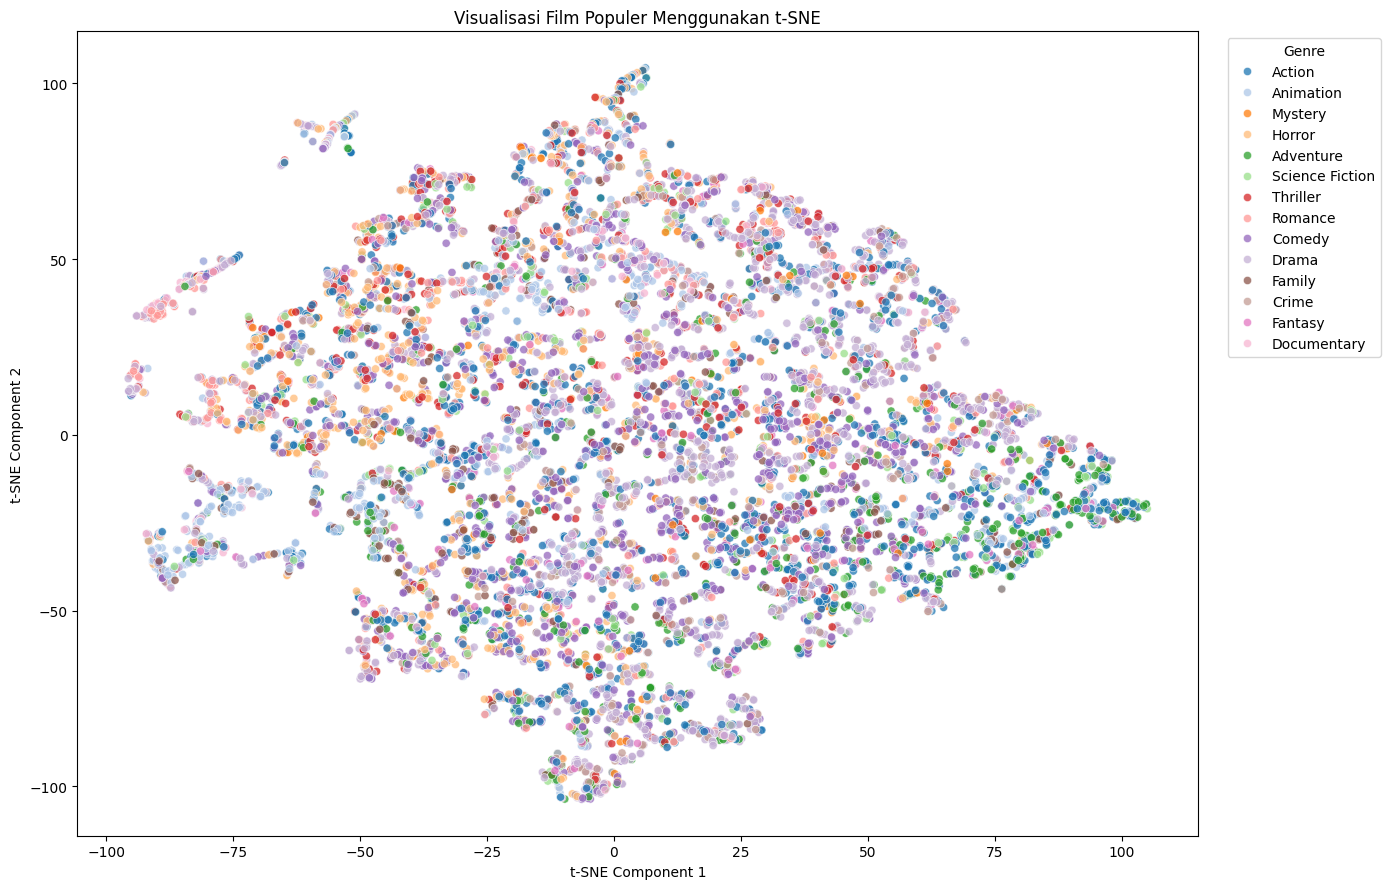

In [58]:
plt.figure(figsize=(14, 9))
sns.scatterplot(
    data=tsne_df,
    x="TSNE1",
    y="TSNE2",
    hue="main_genre",
    palette="tab20",
    alpha=0.75,
    s=35
)
plt.title("Visualisasi Film Populer Menggunakan t-SNE")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title="Genre", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Analisis Hasil t-SNE

Berbeda dengan PCA, visualisasi t-SNE memperlihatkan persebaran data yang lebih luas dan membentuk pola lokal yang lebih beragam. Titik-titik film tampak tersebar ke banyak area dan membentuk kelompok-kelompok kecil, meskipun antar genre masih belum sepenuhnya terpisah secara bersih. Dibandingkan PCA, pola hasil t-SNE terlihat lebih kaya karena metode ini memang lebih fokus pada hubungan kedekatan antar data di tingkat lokal.

Pada grafik t-SNE, beberapa film dengan genre yang sama tampak cenderung berada pada area yang berdekatan, tetapi tetap tidak terkumpul dalam satu cluster tunggal. Sebaliknya, masih ada titik dari genre yang berbeda yang berada pada area yang sama atau saling berdekatan. Hal ini menunjukkan bahwa karakteristik numerik film tidak selalu cukup untuk membedakan genre secara mutlak. Genre film sendiri kemungkinan juga dipengaruhi oleh unsur lain di luar data numerik, seperti tema cerita, gaya penyajian, atau kombinasi multi-genre.

Walaupun begitu, t-SNE tetap memberikan gambaran yang lebih baik dalam melihat pola kedekatan antarfilm. Jika dibandingkan dengan PCA, visualisasi t-SNE membuat struktur data terlihat lebih hidup dan lebih mudah diamati dari sisi kemungkinan pengelompokan lokal.

## Perbandingan PCA dan t-SNE

Secara umum, PCA dan t-SNE sama-sama digunakan untuk mereduksi dimensi data agar lebih mudah divisualisasikan, tetapi hasil yang diberikan pada dataset ini cukup berbeda. PCA menghasilkan visualisasi yang lebih sederhana dan menekankan struktur global data, sehingga cocok untuk melihat persebaran umum film. Namun, pada hasil yang diperoleh, PCA belum mampu menunjukkan pemisahan genre yang cukup jelas karena sebagian besar titik masih menumpuk pada area yang sama.

Sementara itu, t-SNE memberikan visualisasi yang lebih detail dalam menampilkan hubungan lokal antarfilm. Pola persebaran titik terlihat lebih kompleks dan lebih menyebar, sehingga potensi kedekatan antar data lebih mudah diamati. Oleh karena itu, untuk dataset film populer ini, t-SNE dapat dikatakan lebih informatif dibandingkan PCA dalam membantu eksplorasi pola data, meskipun keduanya sama-sama menunjukkan bahwa genre film tidak dapat dipisahkan secara sempurna hanya dengan menggunakan fitur numerik yang tersedia.

## Kesimpulan

Berdasarkan analisis yang telah dilakukan, dataset **Top 1000 Popular Movies TMDB** dapat digunakan dengan baik untuk penerapan dimensionality reduction karena memiliki beberapa fitur numerik yang relevan, seperti rating, jumlah vote, popularitas, budget, revenue, runtime, dan tahun rilis.

Hasil analisis menunjukkan bahwa baik **PCA** maupun **t-SNE** sama-sama mampu mereduksi data film ke dalam ruang dua dimensi sehingga pola persebaran data menjadi lebih mudah diamati. PCA memberikan gambaran umum mengenai struktur global data, sedangkan t-SNE lebih menonjol dalam memperlihatkan hubungan lokal dan kemungkinan pengelompokan data.

Dengan demikian, kedua metode memiliki kelebihan masing-masing. PCA cocok digunakan untuk melihat ringkasan struktur data secara umum, sementara t-SNE lebih cocok jika tujuan analisis adalah mengeksplorasi pola kedekatan dan cluster antar data film.

## Referensi Dataset

Dataset yang digunakan pada tugas ini diambil dari Kaggle:

**Popular Movies Dataset (TMDB)**  
https://www.kaggle.com/datasets/okayyysidd/popular-movies-dataset